## **Introduction**

Cancer is one of the most common and serious health conditions in the United States, affecting millions of people each year. While some risk factors, like genetics, are outside of an individual’s control, many others are related to everyday behaviors such as diet, physical activity, sleep, and substance use. Understanding how these factors are connected to cancer can help identify patterns that may be useful for prevention and early intervention.

In this project, I use data from the National Health Interview Survey (NHIS) to explore whether a person’s health habits and demographic characteristics can be used to predict whether they have ever been diagnosed with cancer. The dataset includes information on age, sex, education, health conditions, and a variety of lifestyle behaviors, making it well-suited for this type of analysis.

To approach this problem, I apply support vector machine (SVM) models with different kernel types (linear, radial, and polynomial). The goal is to compare how well these models perform and to see which variables appear to be most important in predicting cancer. Ultimately, this analysis aims to better understand the relationship between daily habits and cancer outcomes, and to explore how machine learning methods can be used in a public health context.

One could expect age and smoking frequency to be the strongest predictors of cancer diagnosis given their well-established links in epidemiological literature. 




Import the required libraries & dataset

In [3]:
library(e1071)
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element




In [4]:
nhis_df <- read.csv("https://raw.githubusercontent.com/mendible/5322/refs/heads/main/Homework%202/nhis_2022.csv")

head(nhis_df)

,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,PERNUM,NHISPID,HHX,SAMPWEIGHT,⋯,TOMSAUCEMNO,SODAPNO,FRIESPNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,POTATONO,PIZZANO,HRSLEEP,CVDSHT
,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2022,1,143,16,0002022H000001,4,1,0002022H00000110,H000001,8018,⋯,2,0,110,3,0,0,3,2,8,1
2,2022,2,106,53,0002022H000003,3,1,0002022H00000310,H000003,10117,⋯,1,0,1,0,0,1,1,1,6,2
3,2022,2,106,53,0002022H000003,3,2,0002022H00000320,H000003,7933,⋯,996,996,996,996,996,996,996,996,0,2
4,2022,3,134,13,0002022H000006,2,1,0002022H00000610,H000006,2681,⋯,1,1,1,0,2,0,1,1,6,2
5,2022,4,106,53,0002022H000007,3,1,0002022H00000710,H000007,10233,⋯,3,30,5,1,0,30,6,2,8,2
6,2022,4,106,53,0002022H000007,3,2,0002022H00000720,H000007,7712,⋯,996,996,996,996,996,996,996,996,0,1


### Data Cleaning & Preparation

##### Trget Variable and Predictor Selection

A meaningful variable name is also created as CANCEREV doesn't provide much meaning. 

##### Choosing the predictors & Target Variables

The target variable is CANCEREV, which records whether a respondent was ever diagnosed with cancer by a health professional. Valid responses are:

- 1 - No
- 2 - Yes
- 0,7,8,9 - NIU/Unknown(treated as missing)

For analysis purposes, only valid responses (1 = No and 2 = Yes) are typically used. All other categories (0, 7, 8, 9) are treated as missing or invalid responses because they do not provide reliable information about cancer status. To prepare the variable for modeling, it is often recoded into a binary format where “No” is coded as 0 and “Yes” is coded as 1.

The variable is recoded into a binary factor: 0 = No Cancer, 1 = Cancer. All invalid codes are set to NA.
The following variables are excluded from the analysis as they are survey identifiers or design components with no predictive value: YEAR, SERIAL, NHISPID, HHX, STRATA, PSU.
The selected predictors span three themes:
Demographics: Age, Sex, Poverty Ratio
Body Metrics: Weight
Lifestyle Habits: Alcohol consumption, Soda frequency, Sleep hours

In [5]:
library(dplyr)
# Recode target and predictors, setting invalid survey codes to NA
health_data_df <- nhis_df %>%
  mutate(
    # -----------------------------
    # TARGET VARIABLE (Cancer)
    # -----------------------------
  Cancer_Status = factor(
  ifelse(CANCEREV == 2, 1,
  ifelse(CANCEREV == 1, 0, NA)),  # ← correctly sends NIU/unknown to NA
  levels = c(0, 1),
  labels = c("No Cancer", "Cancer")
),

    # -----------------------------
    # DEMOGRAPHICS
    # -----------------------------
    Age_Years = ifelse(AGE %in% c(997, 998, 999), NA, AGE),

    Sex_Category = factor(
      ifelse(SEX %in% c(7, 8, 9), NA, SEX),
      levels = c(1, 2),
      labels = c("Male", "Female")
    ),

    Poverty_Ratio = ifelse(POVERTY %in% c(996, 997, 998, 999), NA, POVERTY),

    # -----------------------------
    # BODY METRICS
    # -----------------------------
    Weight_Lbs = ifelse(WEIGHT %in% c(0, 996, 997, 998,999), NA, WEIGHT),



    # -----------------------------
    # LIFESTYLE HABITS
    # -----------------------------
   

    Alcohol_Days = ifelse(ALCANYNO %in% c(996, 997, 998, 999), NA, ALCANYNO),

    Soda_Frequency = ifelse(SODAPNO %in% c(996, 997, 998, 999), NA, SODAPNO),

    Sleep_Hours = ifelse(HRSLEEP %in% c(0, 97, 98, 99), NA, HRSLEEP)
  )%>% #select the variables of interest
  select(Cancer_Status, Age_Years, Sex_Category, Poverty_Ratio,
         Weight_Lbs, Alcohol_Days, Soda_Frequency, Sleep_Hours)


Note that BMI was initially considered but it was excluded due to its collinearity with Weight — both capture body size, making them redundant as predictors. Smoking Days (CIGDAYMO) is excluded due to 34,421 missing values caused by a survey skip-pattern, as the question was only asked to some-day smokers, making reliable imputation infeasible.

To Assess Missing Values

In [6]:
colSums(is.na(health_data_df))

Cancer_Status      Age_Years   Sex_Category  Poverty_Ratio     Weight_Lbs 
          7501             64              6              0           6605 
  Alcohol_Days Soda_Frequency    Sleep_Hours 
         11550           8519           8436

Variables with missing values after recoding:
* Cancer_Status: 7,501
* Age_Years: 64
* Sex_Category: 6
* Weight_Lbs: 6,373
* Alcohol_Days: 11,550
* Soda_Frequency: 8,519
* Sleep_Hours: 8,436

Variables with very few missing values (Age_Years, Sex_Category) are handled by dropping those rows, as they represent a negligible fraction of the dataset. The target variable Cancer_Status rows with missing values are dropped entirely, as unknown cancer status cannot be reliably inferred. For continuous predictors with moderate missingness, median imputation is applied due to its robustness to skewed distributions common in survey data.

# Exploratory Data Analysis

To inform our imputation strategy, we examine the distribution of each variable with missing values:

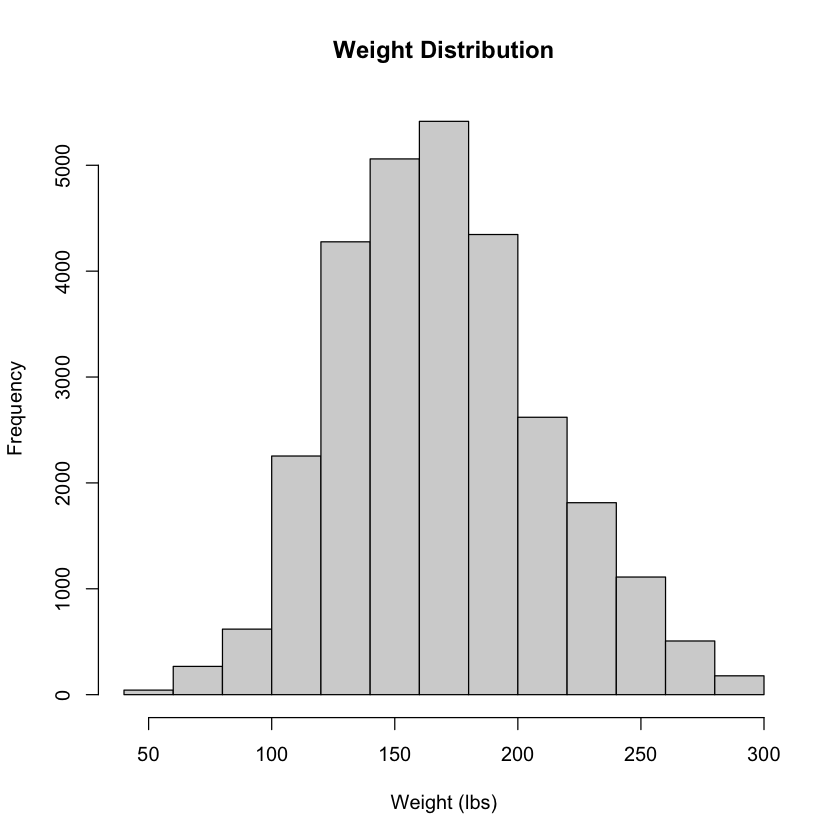

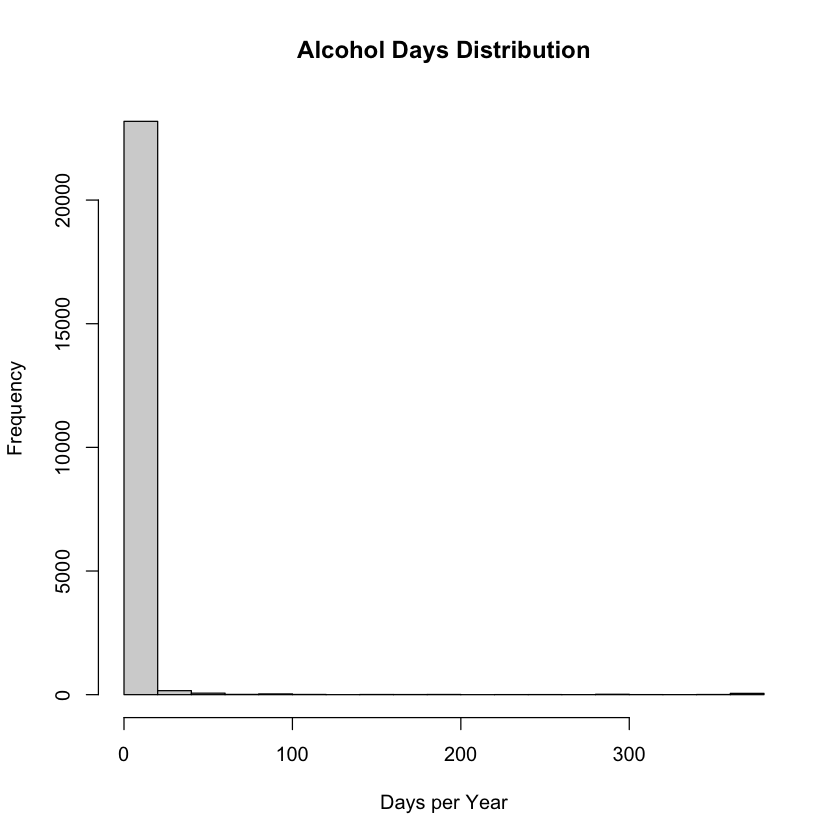

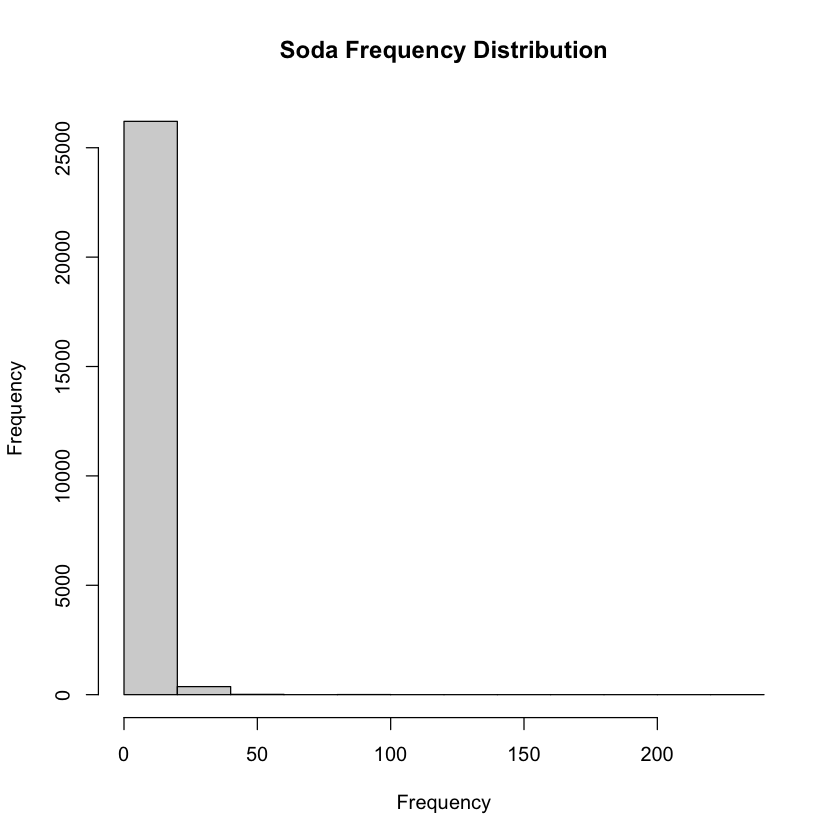

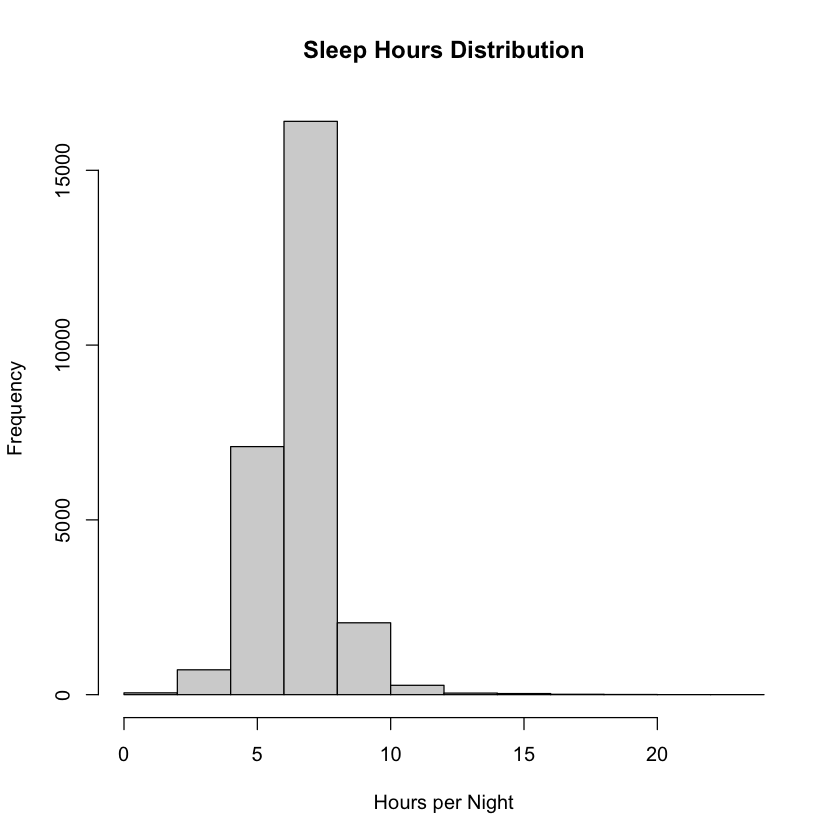

In [7]:
# Visualize distributions to determine imputation method
hist(health_data_df$Weight_Lbs,     main = "Weight Distribution",         xlab = "Weight (lbs)")
hist(health_data_df$Alcohol_Days,   main = "Alcohol Days Distribution",    xlab = "Days per Year")
hist(health_data_df$Soda_Frequency, main = "Soda Frequency Distribution",  xlab = "Frequency")
hist(health_data_df$Sleep_Hours,    main = "Sleep Hours Distribution",      xlab = "Hours per Night")

Alcohol_Days and Soda_Frequency show pronounced right skew, while Weight_Lbs and Sleep_Hours are more symmetric. Median imputation is used for all four variables as it is robust to skewed distributions and outliers, which are common in survey data.

To Impute the Missing Values

In [8]:
# Impute skewed/moderate-NA variables with column median
# Drop remaining rows with NA in Age and Sex (fewer than 70 rows combined)
health_data_df <- health_data_df %>%
  mutate(
    Weight_Lbs     = ifelse(is.na(Weight_Lbs),     median(Weight_Lbs,     na.rm = TRUE), Weight_Lbs),
    Alcohol_Days   = ifelse(is.na(Alcohol_Days),   median(Alcohol_Days,   na.rm = TRUE), Alcohol_Days),
    Soda_Frequency = ifelse(is.na(Soda_Frequency), median(Soda_Frequency, na.rm = TRUE), Soda_Frequency),
    Sleep_Hours    = ifelse(is.na(Sleep_Hours),    median(Sleep_Hours,    na.rm = TRUE), Sleep_Hours)
  ) %>%
  na.omit()

# Verify no missing values remain
colSums(is.na(health_data_df))
nrow(health_data_df)

Cancer_Status      Age_Years   Sex_Category  Poverty_Ratio     Weight_Lbs 
             0              0              0              0              0 
  Alcohol_Days Soda_Frequency    Sleep_Hours 
             0              0              0

[1] 27549

To better understand the relationship between each predictor and the target variable 
`Cancer_Status`, box plots are used rather than scatter plots. Since `Cancer_Status` 
is binary, scatter plots would simply stack points on two horizontal lines, making 
patterns impossible to see. Box plots instead show how the distribution of each 
continuous predictor shifts between the "No Cancer" and "Cancer" groups, allowing us 
to visually identify which variables may be strong predictors before modeling.

In [12]:


# filter Continuous predictors only
continuous_vars <- c("Age_Years", "Poverty_Ratio", "Weight_Lbs",
                     "Alcohol_Days", "Soda_Frequency", "Sleep_Hours")


library(tidyr)

plot_box<-health_data_df %>%
  select(Cancer_Status, all_of(continuous_vars)) %>%
  pivot_longer(cols = -Cancer_Status,
               names_to  = "Variable",
               values_to = "Value") %>%
  ggplot(aes(x = Cancer_Status, y = Value, fill = Cancer_Status)) +
  geom_boxplot(outlier.size = 0.3, alpha = 0.7) +
  facet_wrap(~ Variable, scales = "free_y") +
  scale_fill_manual(values = c("No Cancer" = "steelblue", "Cancer" = "tomato")) +
  labs(
    title = "Predictor Distributions by Cancer Status",
    x     = "Cancer Status",
    y     = "Value"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [13]:
ggsave(
  filename = "cancer_boxplots.png",
  plot = plot_box,
  width = 10,
  height = 6,
  dpi = 300
)

The box plots reveal clear differences in predictor strength. 
**Age_Years** is the strongest predictor, with the Cancer group showing a median age of ~70 compared to 
~50 for No Cancer — a 20-year shift with minimal box overlap. 

**Poverty_Ratio** shows a subtler but meaningful difference, with the Cancer group having a slightly higher 
median and tighter spread, likely reflecting better healthcare access and screening 
among higher-income respondents.
 
 **Alcohol_Days** and **Soda_Frequency** are zero-inflated — the majority of respondents report zero or near-zero values, 
compressing the interquartile range to near zero with heavy users appearing as 
outliers, making these variables poor predictors. 

**Sleep_Hours** and **Weight_Lbs** show near-identical distributions between groups with substantial overlap, confirming 
they offer little individual discriminatory power. Based on these findings, Age_Years 
and Poverty_Ratio are selected as the two strongest predictors for the decision 
boundary visualization.

##### Class Balance Check

Warning message:
“The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.”


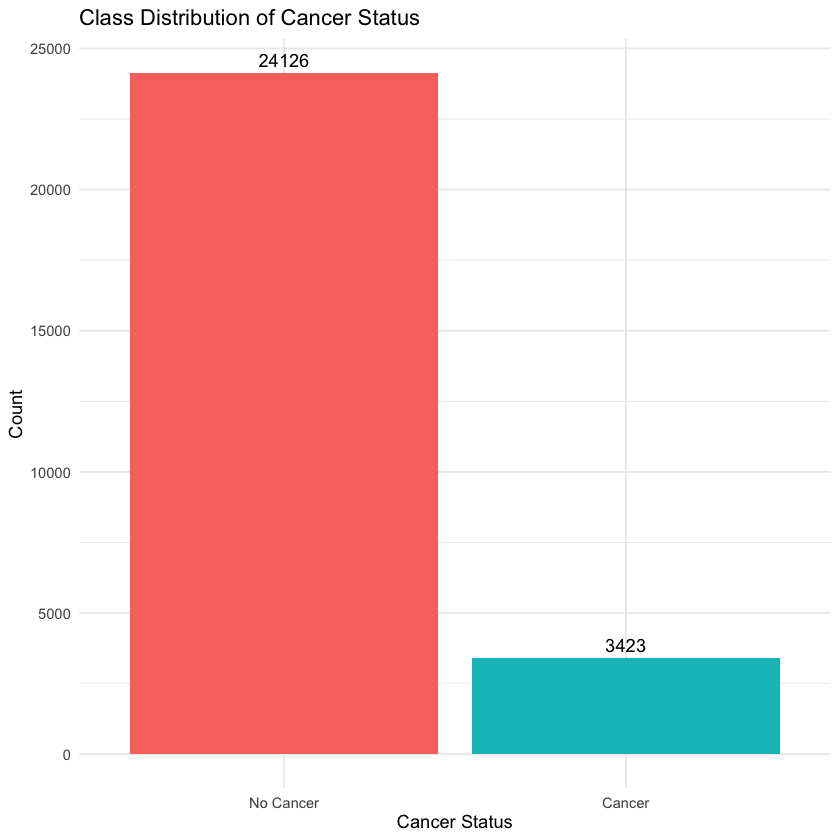

In [10]:
ggplot(health_data_df, aes(x = Cancer_Status, fill = Cancer_Status)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = ..count..), vjust = -0.5) +
  labs(
    title = "Class Distribution of Cancer Status",
    x = "Cancer Status",
    y = "Count"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

 
 

Cancer prevalence in the NHIS is typically around 10–12%, which creates class imbalance. If left unaddressed, models may be biased toward predicting "No Cancer" for all observations, inflating accuracy while failing to detect true cases.


## Modelling

#### Train/Test Split

In [ ]:
#split data using 80:20 split
set.seed(2)
index <- sample(1:nrow(health_data_df), 0.8 * nrow(health_data_df))
train_df  <- health_data_df[index, ]
test_df   <- health_data_df[-index, ]

In [ ]:
summary(train_df[, c("Age_Years", "Poverty_Ratio", "Weight_Lbs",
                     "Alcohol_Days", "Soda_Frequency", "Sleep_Hours")])

   Age_Years  Poverty_Ratio     Weight_Lbs     Alcohol_Days   
 Min.   :18   Min.   :11.00   Min.   :100.0   Min.   :  0.00  
 1st Qu.:37   1st Qu.:24.00   1st Qu.:150.0   1st Qu.:  1.00  
 Median :54   Median :34.00   Median :170.0   Median :  2.00  
 Mean   :53   Mean   :30.47   Mean   :176.4   Mean   :  3.91  
 3rd Qu.:68   3rd Qu.:37.00   3rd Qu.:200.0   3rd Qu.:  3.00  
 Max.   :85   Max.   :37.00   Max.   :298.0   Max.   :365.00  
 Soda_Frequency     Sleep_Hours    
 Min.   :  0.000   Min.   : 1.000  
 1st Qu.:  0.000   1st Qu.: 6.000  
 Median :  1.000   Median : 7.000  
 Mean   :  1.785   Mean   : 7.135  
 3rd Qu.:  2.000   3rd Qu.: 8.000  
 Max.   :240.000   Max.   :24.000  

2. Use weighted classes

Given the class imabalance in the for Cancer status - with ~25000 observations reporting 'No Cancer' and ~3500 respondents reporting 'Cancer'. Weighting the minority class based on its frequency will help prevent the model from predicting No Cancer for all observations.

In [ ]:
class_counts <- table(train_df$Cancer_Status)
class_counts

#to compute class weights
class_weights <- max(class_counts)/class_counts
class_weights


No Cancer    Cancer 
    19285      2754 


No Cancer    Cancer 
 1.000000  7.002542 

The 'No Cancer' class gets a class weight of 1 while the 'Cancer' class will be assigned a class weight of 7. 

# Modelling

Once the dataset has been split into training and testing sets and class weights have been computed, we can proceed to model training. Before fitting the model, however, we need to specify key hyperparameters—such as the cost parameter in SVMs—that control how the model learns. To identify the most effective configuration, we perform hyperparameter tuning to search for the optimal parameter values.

##### Model 1: Linear Kernel (Tuning)

In [ ]:
set.seed(2)
linear_tuning <- tune(
  svm,
  Cancer_Status ~ .,
  data   = train_df,
  kernel = "linear",
  ranges = list(cost = c(0.01, 0.1, 1, 10)),
  scale  = TRUE,
  class.weights = class_weights
)
summary(linear_tuning)
best_linear <- linear_tuning$best.model


Parameter tuning of ‘svm’:

- sampling method: 10-fold cross validation 

- best parameters:
 cost
   10

- best performance: 0.3560957 

- Detailed performance results:
   cost     error  dispersion
1  0.01 0.3567309 0.008856297
2  0.10 0.3562317 0.009094209
3  1.00 0.3561410 0.008920023
4 10.00 0.3560957 0.008864422


The best cost parameter and corresponding cross-validation error are reported 
in the tuning summary above.

##### Refit Linear Kernel Using Best Param

In [ ]:
svm_linear <- svm(
    Cancer_Status ~ .,
    data = train_df,
    kernel = "linear",
    cost = linear_tuning$best.parameters$cost,
    scale = TRUE,
    class.weights = class_weights

)

##### Model 2: Radial Kernel (Tuning)

In [ ]:
set.seed(2)
radial_tuning <- tune(
  svm,
  Cancer_Status ~ .,
  data   = train_df,
  kernel = "radial",
  ranges = list(
    cost = c(0.01, 0.1, 1, 10),# controls how much the SVM penalizes misclassified points.
    gamma = c(0.01, 0.1, 1, 10) # Gamma controls how far the influence of a single training point reaches
  ),
  scale  = TRUE,
  class.weights = class_weights
)
summary(radial_tuning)
best_radial <- radial_tuning$best.model


Parameter tuning of ‘svm’:

- sampling method: 10-fold cross validation 

- best parameters:
 cost gamma
   10    10

- best performance: 0.1870317 

- Detailed performance results:
    cost gamma     error  dispersion
1   0.01  0.01 0.3796451 0.007987759
2   0.10  0.01 0.3666680 0.008520207
3   1.00  0.01 0.3833659 0.008030140
4  10.00  0.01 0.4090475 0.010284105
5   0.01  0.10 0.3761968 0.008504091
6   0.10  0.10 0.3805981 0.008265308
7   1.00  0.10 0.3620400 0.009253679
8  10.00  0.10 0.3508781 0.009718910
9   0.01  1.00 0.3306409 0.009994699
10  0.10  1.00 0.3365851 0.011048291
11  1.00  1.00 0.3158491 0.010579967
12 10.00  1.00 0.2991510 0.010322872
13  0.01 10.00 0.4868366 0.378436001
14  0.10 10.00 0.2231495 0.007790200
15  1.00 10.00 0.2127132 0.008131912
16 10.00 10.00 0.1870317 0.006302885


##### Refit Radial Kernel Using Best Param

In [ ]:
svm_radial <- svm(
  Cancer_Status ~ .,
  data          = train_df,
  kernel        = "radial",
  cost          = radial_tuning$best.parameters$cost,
  gamma         = radial_tuning$best.parameters$gamma,
  scale         = TRUE,
  class.weights = class_weights
)

##### Model 3: Polynomial Kernel (Tuning)

To perform parameter tuning for the Polynomial Kernel, we include a range of values for the cost and the degree parameters. 

In [ ]:
set.seed(2)
poly_tuning <- tune(
  svm,
  Cancer_Status ~ .,
  data   = train_df,
  kernel = "polynomial",
  ranges = list(
    cost   = c(0.1, 1, 10),# controls how much the SVM penalizes misclassified points.
    degree = c(2, 3, 4)
  ),
  scale  = TRUE,
  class.weights = class_weights
)
summary(poly_tuning)
best_poly <- poly_tuning$best.model


Parameter tuning of ‘svm’:

- sampling method: 10-fold cross validation 

- best parameters:
 cost degree
  0.1      4

- best performance: 0.3101775 

- Detailed performance results:
  cost degree     error  dispersion
1  0.1      2 0.4156724 0.015410351
2  1.0      2 0.4193475 0.010386966
3 10.0      2 0.4180317 0.010632094
4  0.1      3 0.3442533 0.009229751
5  1.0      3 0.3761511 0.008310263
6 10.0      3 0.3725667 0.008235363
7  0.1      4 0.3101775 0.011390168
8  1.0      4 0.3335450 0.008899992
9 10.0      4 0.4151241 0.162367396


The best combination of cost and degree parameters, along with the corresponding 
cross-validation error, are reported in the tuning summary above.





##### Refit Polynomial Kernel Using Best Param

In [ ]:
svm_poly <- svm(
  Cancer_Status ~ .,
  data          = train_df,
  kernel        = "polynomial",
  cost          = poly_tuning$best.parameters$cost,
  degree        = poly_tuning$best.parameters$degree,
  scale         = TRUE,
  class.weights = class_weights
)

##### Make Prediction Using the fitted Models

After obtaining the refitted models, the models can be used to make prediction using unseen data(test set).

In [ ]:
pred_linear <- predict(svm_linear, newdata = test_df)
pred_radial <- predict(svm_radial, newdata = test_df)
pred_poly   <- predict(svm_poly,   newdata = test_df)

## Model Evaluation


Model:     Linear Kernel
Accuracy:  0.6352
Precision: 0.2217
Recall:    0.7982
F1 Score:  0.347 


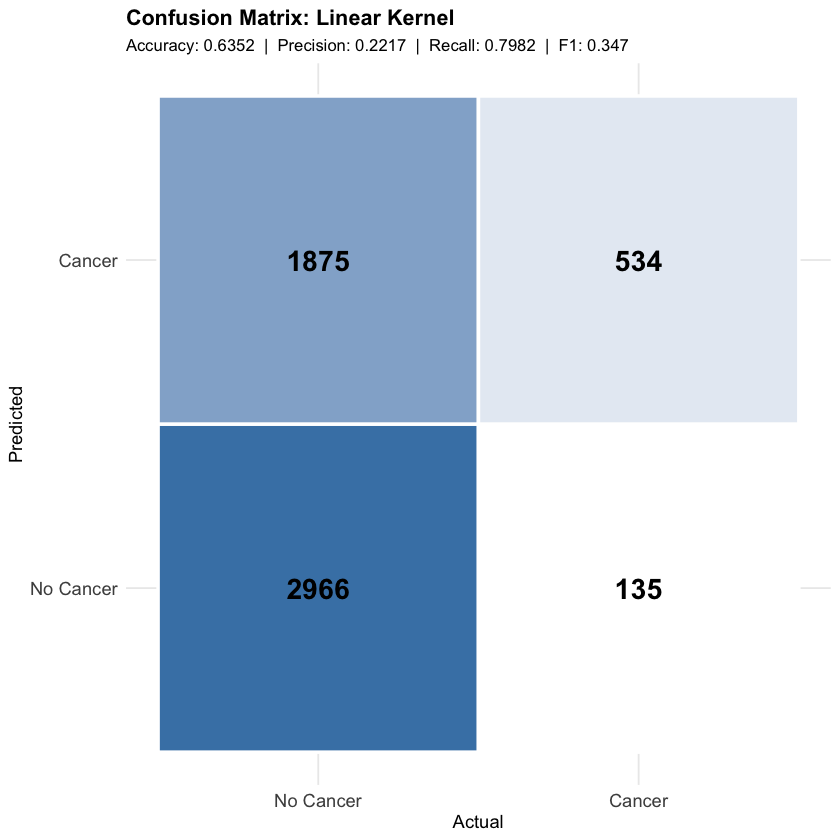


Model:     Radial Kernel
Accuracy:  0.8062
Precision: 0.2
Recall:    0.1988
F1 Score:  0.1994 


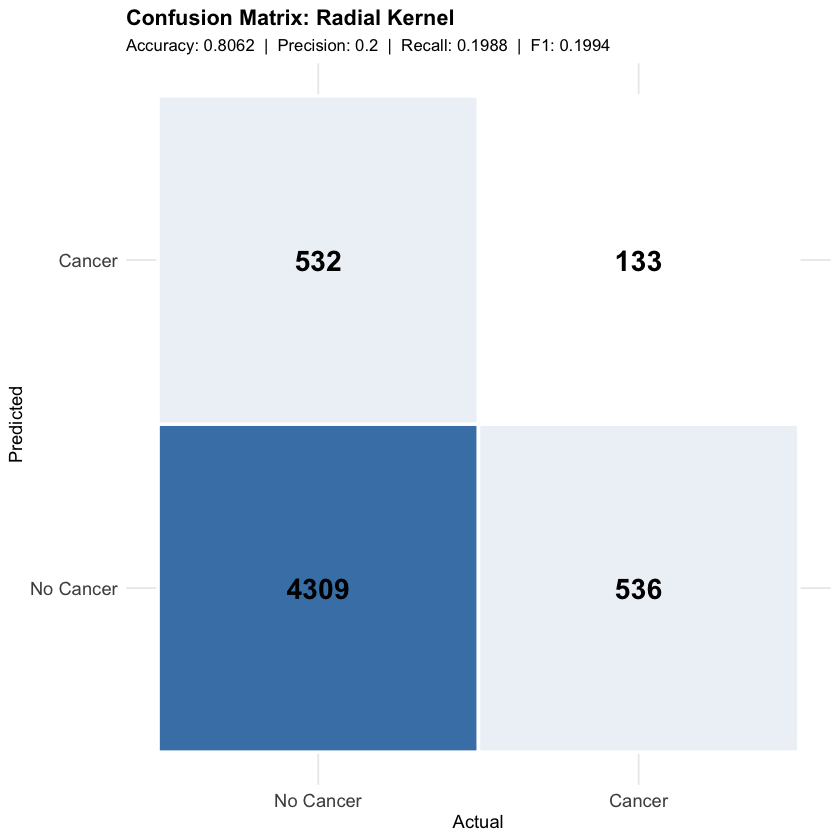


Model:     Polynomial Kernel
Accuracy:  0.6782
Precision: 0.2366
Recall:    0.7414
F1 Score:  0.3588 


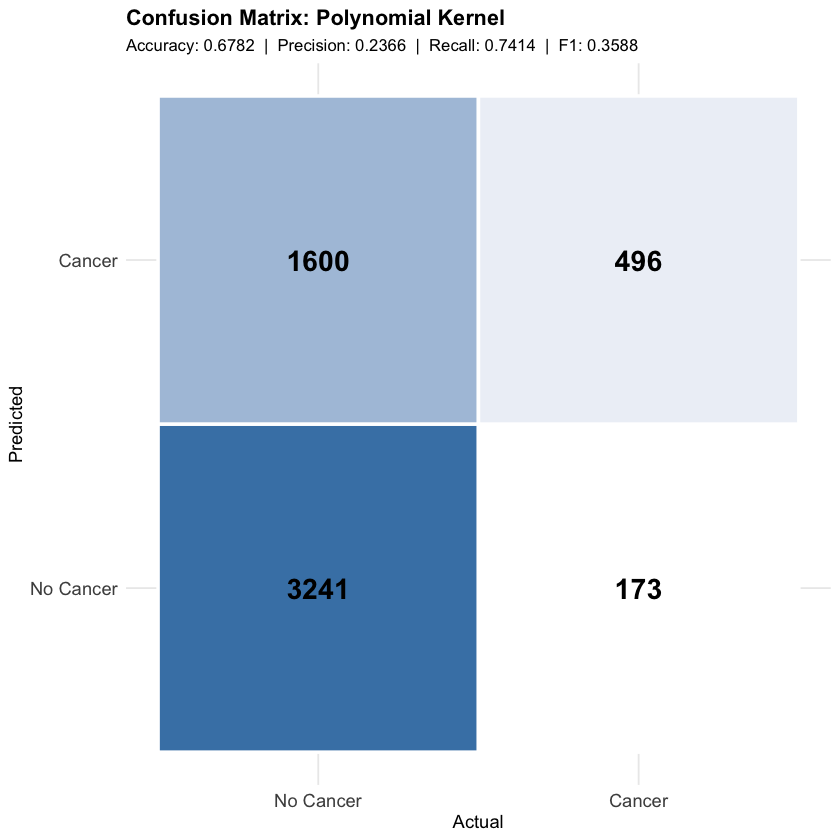

In [ ]:
library(ggplot2)

# Define function that takes predictions, actual labels, and model name
# and outputs accuracy, precision, recall, and F1 score
evaluate_model <- function(preds, actual, model_name) {
  
  # Build confusion matrix from predictions vs actual labels
  conf_mat <- table(Predicted = preds, Actual = actual)
  
  # Compute overall accuracy
  acc <- sum(diag(conf_mat)) / sum(conf_mat)
  
  # Extract TP, FN, TN, FP from confusion matrix
  TP <- conf_mat["Cancer", "Cancer"]
  FN <- conf_mat["No Cancer", "Cancer"]
  TN <- conf_mat["No Cancer", "No Cancer"]
  FP <- conf_mat["Cancer", "No Cancer"]
  
  # Recall: proportion of actual Cancer cases correctly identified (primary metric)
  recall <- TP / (TP + FN)
  
  # Precision: of all predicted Cancer, how many were actually Cancer
  precision <- TP / (TP + FP)
  
  # F1: harmonic mean of precision and recall — key metric for imbalanced classification
  f1 <- 2 * (precision * recall) / (precision + recall)
  
  # Convert confusion matrix to dataframe for ggplot
  conf_mat_df <- as.data.frame(conf_mat)
  
  # Plot confusion matrix (heatmap style)
  p <- ggplot(conf_mat_df, aes(x = Actual, y = Predicted, fill = Freq)) +
    geom_tile(color = "white", linewidth = 1) +
    geom_text(aes(label = Freq), size = 6, fontface = "bold") +
    scale_fill_gradient(low = "white", high = "steelblue") +
    labs(
      title    = paste("Confusion Matrix:", model_name),
      subtitle = paste0("Accuracy: ",     round(acc,       4),
                        "  |  Precision: ", round(precision, 4),
                        "  |  Recall: ",    round(recall,    4),
                        "  |  F1: ",        round(f1,        4)),
      x = "Actual",
      y = "Predicted"
    ) +
    theme_minimal() +
    theme(
      legend.position = "none",
      plot.title      = element_text(face = "bold", size = 13),
      plot.subtitle   = element_text(size = 10),
      axis.text       = element_text(size = 11)
    )
  
  print(p)
  
  
  cat("\nModel:    ", model_name)
  cat("\nAccuracy: ", round(acc,       4))
  cat("\nPrecision:", round(precision, 4))
  cat("\nRecall:   ", round(recall,    4))
  cat("\nF1 Score: ", round(f1,        4), "\n")
}

# Evaluate all three models on the held-out test set
evaluate_model(pred_linear, test_df$Cancer_Status, "Linear Kernel")
evaluate_model(pred_radial, test_df$Cancer_Status, "Radial Kernel")
evaluate_model(pred_poly,   test_df$Cancer_Status, "Polynomial Kernel")

## Model Comparison

The three SVM kernels show notably different performance scores across board. The radial kernel 
achieves the highest accuracy (0.81) but the lowest recall (0.20), indicating it 
predicts No Cancer for the majority of observations — a consequence of class imbalance 
inflating accuracy while the model fails to detect true cancer cases. This makes the 
radial kernel the weakest performer for this task despite its high accuracy.

The linear kernel achieves the highest recall (0.80), successfully identifying 80% of 
true cancer cases, but at the cost of low precision (0.22) — meaning many healthy 
respondents are incorrectly flagged as having cancer. This results in a moderate F1 
score of 0.35.

The polynomial kernel offers the best overall balance, achieving the highest F1 score 
(0.36) with strong recall (0.74) and slightly better precision (0.24) than the linear 
kernel. It correctly identifies the majority of cancer cases while generating fewer 
false positives than the linear model.

From a medical context where inaccurate cancer screening could be a very costly error - often leading to one not detecting cancer early and taking proper steps to treat it - the linear kernel's superior recall makes it clinically preferable. However if minimizing unnecessary follow ups is what is most important then the Polynomial kernel's better F1 score makes it the more balanced choice. The radial kernel is not recommended given the presence of high class imbalance despite its very high accuracy(accuracy is misleading).


### Decision Boundary Plot

To visualize how the SVM separates the two classes, we refit the radial kernel 
on the two strongest continuous predictors — Age_Years and Weight_Lbs. While 
Poverty_Ratio showed a clearer separation in the box plots, it is a discrete 
variable that produces vertical striping in the decision boundary plot, making 
it harder to interpret visually. Weight_Lbs is used as the second predictor for 
a smoother, more readable boundary.

To create the plot, we need to refit the one of the models - the radial SVM with the two predictors using the best parameters obtained earlier.


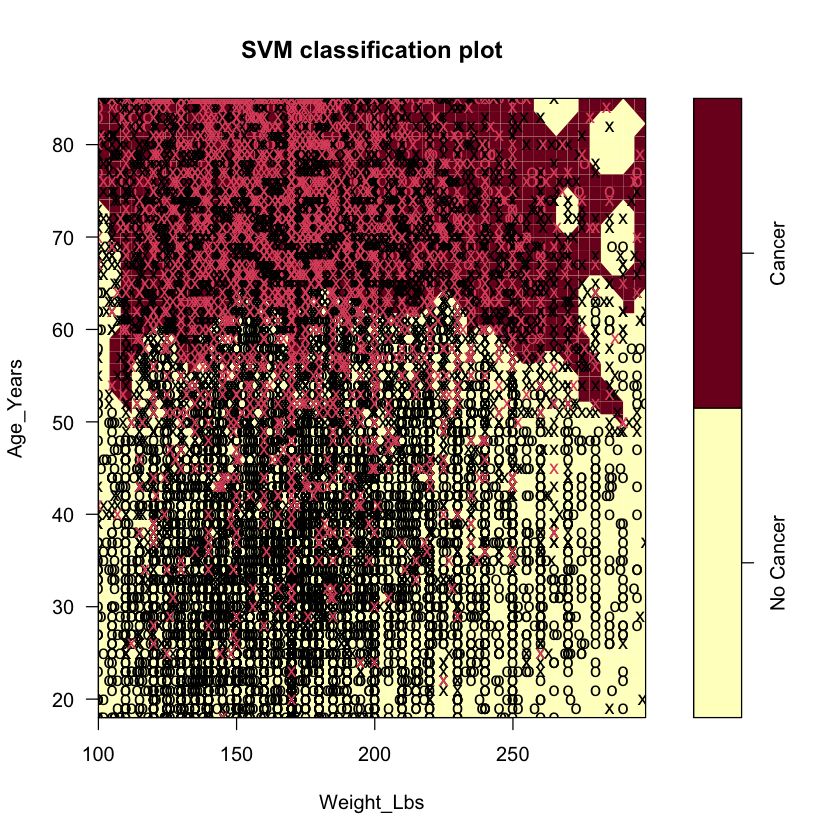

In [ ]:
# Refit on Age + Weight using best parameters obtained during tuning
set.seed(2)
svm_2d <- svm(
  Cancer_Status ~ Age_Years + Weight_Lbs,
  data          = train_df,
  kernel        = "radial",
  cost          = radial_tuning$best.parameters$cost,
  gamma         = radial_tuning$best.parameters$gamma,
  scale         = TRUE,
  class.weights = class_weights
)

plot(svm_2d, train_df,
     Age_Years ~ Weight_Lbs,
     main = "Radial Kernel: Age vs Weight")

The SVM classification plot displays the radial kernel decision boundary across Age_Years 
and Weight_Lbs. The background shading represents the model's predicted regions — dark red 
for Cancer and light yellow for No Cancer — while the symbols indicate prediction accuracy: 
X marks correctly classified points and O marks misclassified points. The boundary falls 
roughly between ages 55–65, above which the model predominantly predicts Cancer and below 
which it predicts No Cancer, consistent with the strong age effect observed in the box plots. 
Weight_Lbs appears to have minimal influence on the boundary, with the separation driven 
almost entirely by age. The transition zone between ages 50–65 contains the most 
misclassifications, reflected by the dense concentration of O symbols, which is expected 
given that cancer prevalence is more mixed in middle-aged respondents. 

## Conclusions

This analysis applied three SVM kernel types — linear, radial, and polynomial — to 
predict cancer diagnosis using demographic and lifestyle variables from the 2022 
National Health Interview Survey.

**Key findings:**

**Age** emerged as the dominant predictor of cancer status, with the SVM decision 
boundary falling between ages 55–65 — consistent with well-established evidence that 
cancer risk increases substantially with age. The 20-year median difference between 
cancer and non-cancer groups observed in the box plots was the clearest signal in the 
data. 

**Poverty_Ratio** showed a weak secondary signal. Both groups have incomes around 
3–3.5x the poverty line on average, with the Cancer group showing a slightly higher 
median and tighter spread. This modest difference may reflect marginally better 
healthcare access and screening among higher-income respondents rather than a true 
increase in disease burden. Lifestyle variables — alcohol consumption, soda frequency, 
sleep hours, and weight — showed minimal individual discriminatory power, suggesting 
these factors alone are insufficient predictors of cancer diagnosis in this dataset.

Among the three kernels, the **polynomial kernel** (F1: 0.3588, Recall: 0.7414) 
offered the best balance between identifying true cancer cases and avoiding false 
alarms. The **linear kernel** (Recall: 0.7982) is preferred in a strict screening 
context where missing a cancer diagnosis is the costliest error. The **radial kernel**, 
despite its high accuracy (0.8062), failed to detect the minority class effectively 
(Recall: 0.1988), making it unsuitable for imbalanced classification tasks without 
further tuning.



**Policy Implications:**
The findings from this project suggest that age-targeted cancer screening programs, 
particularly for individuals over 60, could be an effective early detection strategy 
given that age was the dominant predictor of cancer diagnosis across all three models.

Poverty_Ratio showed minimal predictive power, with both cancer and non-cancer groups 
having similar income levels of around 3–3.5x the federal poverty line. This limits 
any meaningful policy conclusions around income and cancer risk from this dataset.

Future analyses should analyze other predictors in the NHIS dataset such as smoking history and other physical activity. 
but are well-established cancer risk factors. Additionally, exploring alternative 
approaches to handling class imbalance — such as SMOTE oversampling or cost-sensitive 
learning — may further improve model sensitivity and overall performance.Additionally, exploring alternative 
approaches to handling class imbalance — such as SMOTE oversampling or cost-sensitive 
learning — may further improve model sensitivity and overall performance.